# Perform ARIMA analysis on the data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.time import Time
from statsmodels.tsa.arima.model import ARIMA
from matplotlib.ticker import MultipleLocator
from scipy.stats import boxcox

- Let us work with PD here for simplicity. 

In [3]:
data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)
data.columns = ["JD", "sind"]
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')
data


C:\Users\Joey\AppData\Local\Temp\ipykernel_23328\2443593090.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)


,JD,sind,year
datetime,,,
1966-09-02 08:34:04.799986,2439370.857,0.173873,1966.669013
1966-09-03 08:13:55.199989,2439371.843,0.175041,1966.671713
1966-09-04 07:55:12.000006,2439372.830,0.174457,1966.674415
1966-09-24 08:16:48.000018,2439392.845,0.175236,1966.729213
1966-09-25 07:56:38.399980,2439393.831,0.175918,1966.731912
...,...,...,...
1991-08-26 16:59:31.200009,2448495.208,0.181948,1991.650125
1991-08-28 16:59:31.200009,2448497.208,0.177421,1991.655600
1991-08-29 16:59:31.200009,2448498.208,0.179252,1991.658338


- *We can refit on train and valid before test set evaluation*

In [72]:
# Downsample before split

data_df_year = data.resample('YE').median().interpolate('time', limit =5) # resample years into groups, asfreq takes one per group 
data_df_6me = data.resample('6ME').median().interpolate('time', limit = 6)
data_df_me = data.resample('ME').median().interpolate('time', limit = 6)
data_df_gapme = data[data['year'] > 1973].resample('ME').median().interpolate('time', limit = 6) # use all data after 1973

In [73]:
def split_df(df, train_split=0.8, valid_split=0.1):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

train_df, valid_df, test_df = split_df(data)
train_df_year,  valid_df_year,  test_df_year  = split_df(data_df_year)
train_df_6me,   valid_df_6me,   test_df_6me   = split_df(data_df_6me)
train_df_me,    valid_df_me,    test_df_me    = split_df(data_df_me)
train_df_gapme, valid_df_gapme, test_df_gapme = split_df(data_df_gapme)

for name, (train, valid, test) in {
    "data" : (train_df, valid_df, test_df),
    "year"  : (train_df_year,  valid_df_year,  test_df_year),
    "6me"   : (train_df_6me,   valid_df_6me,   test_df_6me),
    "me"    : (train_df_me,    valid_df_me,    test_df_me),
    "gapme" : (train_df_gapme, valid_df_gapme, test_df_gapme),
}.items():
    print(f"{name:>6} → train: {train.shape}, valid: {valid.shape}, test: {test.shape}")

  data → train: (1353, 3), valid: (169, 3), test: (169, 3)
  year → train: (21, 3), valid: (2, 3), test: (3, 3)
   6me → train: (41, 3), valid: (5, 3), test: (5, 3)
    me → train: (240, 3), valid: (30, 3), test: (30, 3)
 gapme → train: (168, 3), valid: (21, 3), test: (21, 3)


- Now we want to check for stationarity to make sure the ARIMA model is applicable.
- Let us examine the training dataset to prevent data leakage.

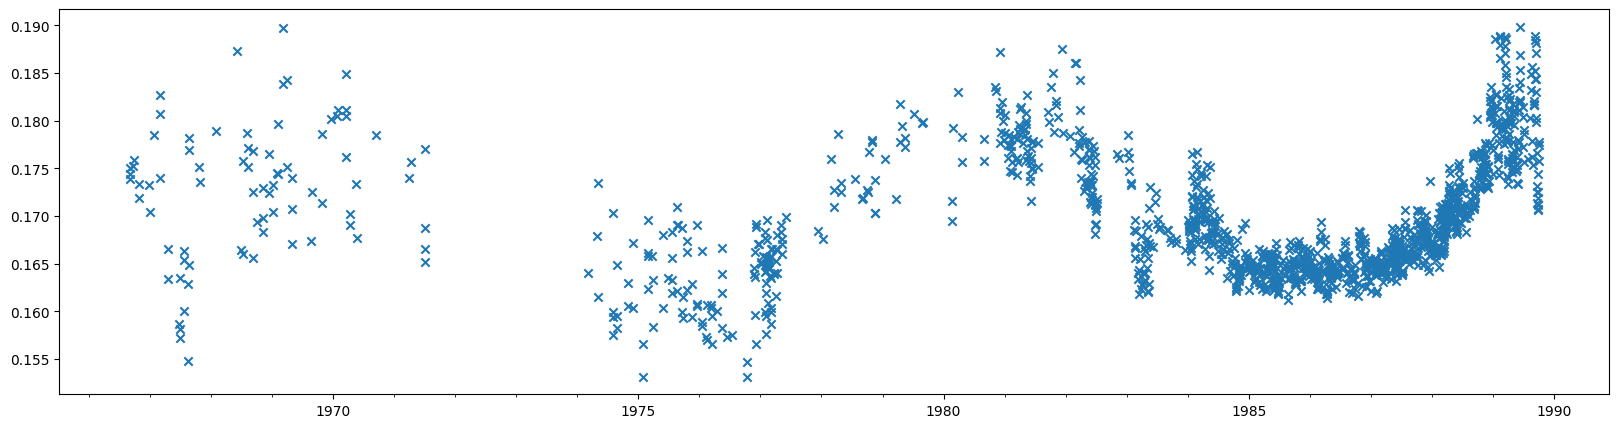

In [74]:
fig, ax = plt.subplots(figsize=(20,5))
plt.scatter(train_df["year"], train_df['sind'], marker='x')
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

- Looks vaguely sinusoidal
- Peaks at 1970ish and 1981ish
- Troughs at 1976ish and 1986ish
- This corresponds to the roughly 10 to 11 year solar cycle

----

- The variance of the data does not look constant
- We can check the mean of the data by checking the average values at the minima we have observed

In [75]:
trough1976 = data[data['year'].between(1975,1977)]
trough1986 = data[data['year'].between(1985,1987)]
mean1976 = trough1976['sind'].mean()
mean1986 = trough1986['sind'].mean()
mean_delta = abs(mean1976-mean1986)
data_range = data['sind'].max() - data['sind'].min()
print(f"The change in means is {mean_delta} out of overall range delta {data_range}")
print(f'Percentage {100*mean_delta/data_range:.2f}%')


The change in means is 0.0019412766020864003 out of overall range delta 0.03818200000000002
Percentage 5.08%


- This seems similar enough considering the uncertainty in the estimating the trough.
- Now how to fix the variance.
- No idea how the variance varies so use a Box-Cox transform to normalise.

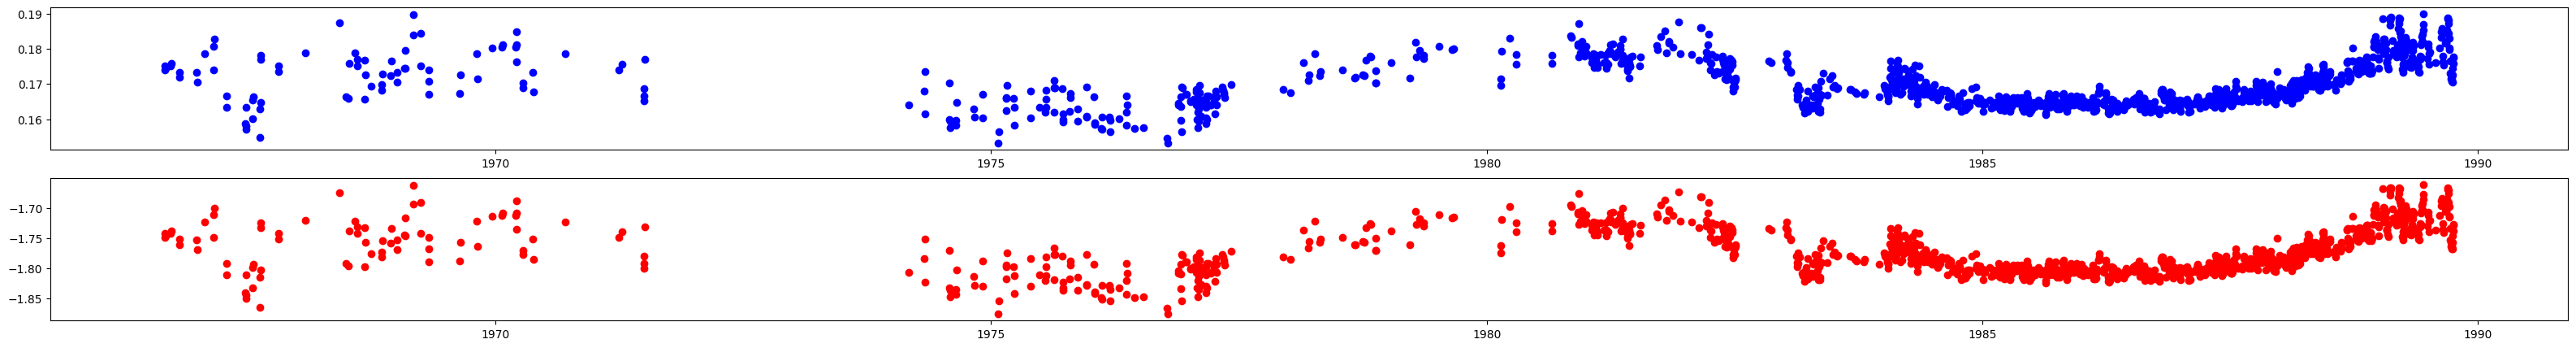

In [76]:
# train_df['sind_norm'], lambda_ = boxcox(train_df['sind']) 
train_df['sind_norm'] = np.log(train_df['sind'])
fig, ax = s=plt.subplots(2,1 ,figsize=(40,5))
ax[0].scatter(train_df['year'], train_df['sind'], color = 'blue')
ax[1].scatter(train_df['year'], train_df['sind_norm'], color = 'red')
# lambda_

In [77]:
# Apply the log transform to all 4

train_df_year['sind_norm'] = np.log(train_df_year['sind'])
train_df_6me['sind_norm'] = np.log(train_df_6me['sind'])
train_df_me['sind_norm'] = np.log(train_df_me['sind'])
train_df_gapme['sind_norm'] = np.log(train_df_gapme['sind'])


- The next problem is that the data is not at fixed timesteps. 
- That four year gap is really problematic. Let's try interpolating it.
- This is still problematic. If we downsample to years we have very few datapoints but if we downsample to months we have too many interpolated ones. 
- Some approaches to try approaches:
    - Downsample to years; interpolate gap. 
    - Downsample to 6 months; reduced gap interpolation.
    - Downsample to months; massive interpolation.
    - Start analysis after gap; interp to month.
- The downsampling restricts the resolution of the solar cycle predictions.

In [78]:
na = [train_df_year.isna().sum(),
      train_df_6me.isna().sum(),
      train_df_me.isna().sum(),
      train_df_gapme.isna().sum(),
      ]

pd.set_option('display.max_rows', None)
print(na)
pd.reset_option('display.max_rows')

[JD           0
sind         0
year         0
sind_norm    0
dtype: int64, JD           0
sind         0
year         0
sind_norm    0
dtype: int64, JD           25
sind         25
year         25
sind_norm    25
dtype: int64, JD           0
sind         0
year         0
sind_norm    0
dtype: int64]


- The train_df_me has NaN values so let's skip that dataset.

In [79]:
from math import floor
# Print maxlags
def max_lags(df):
    n = len(df['sind_norm'])
    return floor(n/2)

print(f"{len(train_df_year)} datapoints in train_df_year, max lags = {max_lags(train_df_year)}")
print(f"{len(train_df_6me)} datapoints in train_df_6me, max lags = {max_lags(train_df_6me)}")
print(f"{len(train_df_gapme)} datapoints in train_df_gapme, max lags = {max_lags(train_df_gapme)}")


21 datapoints in train_df_year, max lags = 10
41 datapoints in train_df_6me, max lags = 20
168 datapoints in train_df_gapme, max lags = 84


- Now let's plot the ACF and PACF.
- Note to self: 
    - ACF is the correlation between a series and a lagged version of itself.
    - PACF is the correlation between a series and a lagged version with indirect effects removed.
    - The shaded bands indicate the regions in which the values would fall if they were white noise.

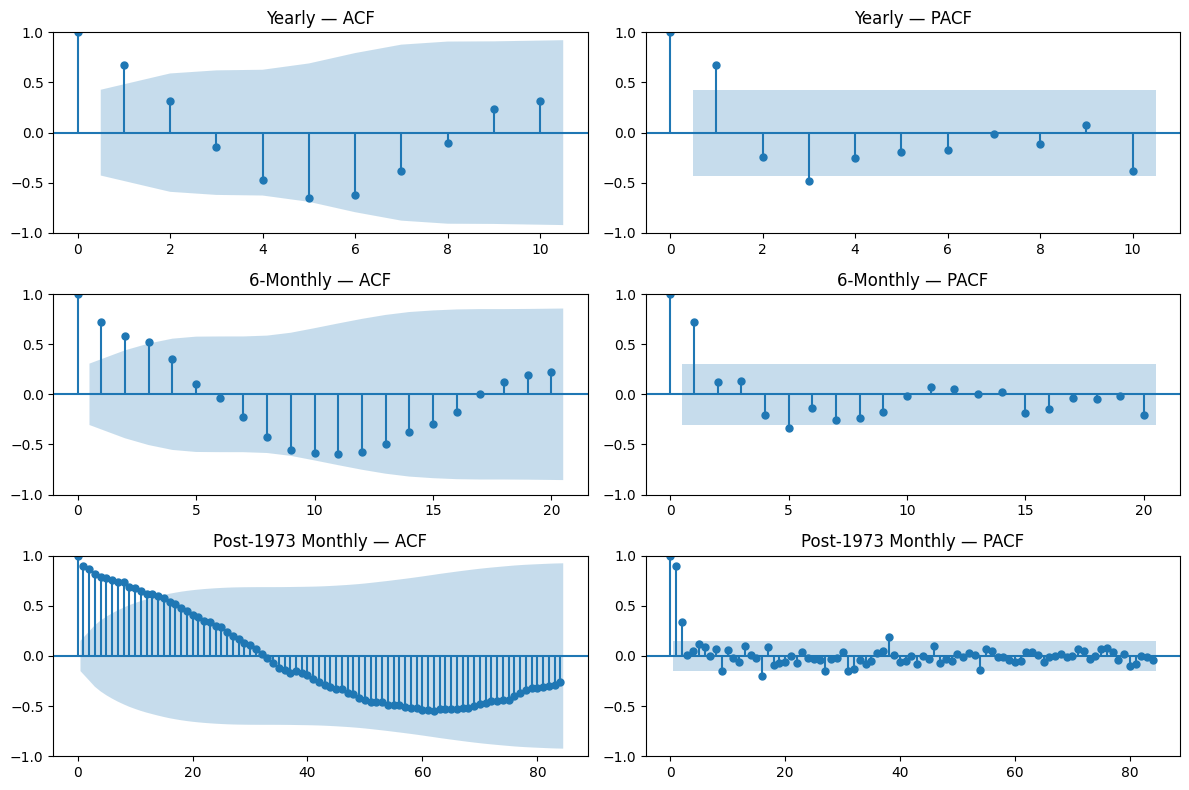

In [80]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(3, 2, figsize=(12, 8))

plot_acf(train_df_year['sind_norm'],   lags=10, ax=ax[0,0])
plot_pacf(train_df_year['sind_norm'],  lags=10, ax=ax[0,1])
ax[0,0].set_title('Yearly — ACF')
ax[0,1].set_title('Yearly — PACF')

plot_acf(train_df_6me['sind_norm'],    lags=20, ax=ax[1,0])
plot_pacf(train_df_6me['sind_norm'],   lags=20, ax=ax[1,1])
ax[1,0].set_title('6-Monthly — ACF')
ax[1,1].set_title('6-Monthly — PACF')

plot_acf(train_df_gapme['sind_norm'],  lags=84, ax=ax[2,0])
plot_pacf(train_df_gapme['sind_norm'], lags=84, ax=ax[2,1])
ax[2,0].set_title('Post-1973 Monthly — ACF')
ax[2,1].set_title('Post-1973 Monthly — PACF')

plt.tight_layout()
plt.show()

- The annual and semi-annual data downsamples show cyclic behaviour within 11 yeah cycles. 
    - The PACFs of these are dominated by the first two terms. This could be AR(2) (q=2)
- The monthly shows a negative correlation at 60 months =  5 years = aprox. half the solar cycle.

##### Actually training the ARIMAs

- pmdarima implements the rather nifty Hyndman-Khandakar search algo for p and q.
- I have decided on no differencing.
- Used AICc to correct for small sample sizes.

In [81]:
import pmdarima as pm
model_year = pm.auto_arima(
    train_df_year['sind_norm'],
    seasonal = False, # the cycle is longer than that
    start_q = 2,
    stepwise = True,
    information_criterion='aicc',
    d = 0,
    maxp = 10,
    maxq = 10,
    trace = True
)

model_6me = pm.auto_arima(
    train_df_6me['sind_norm'],
    seasonal = False, # the cycle is longer than that
    start_q = 2,
    stepwise = True,
    information_criterion='aicc',
    d = 0,
    maxp = 10,
    maxq = 10,
    trace = True
)
model_gapme = pm.auto_arima(
    train_df_gapme['sind_norm'],
    seasonal = False, # the cycle is longer than that
    start_q = 2,
    stepwise = True,
    information_criterion='aicc',
    d = 0,
    maxp = 10,
    maxq = 10,
    trace = True
)

Performing stepwise search to minimize aicc
 ARIMA(2,0,2)(0,0,0)[0]             : AICC=inf, Time=0.39 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AICC=85.873, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AICC=inf, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AICC=inf, Time=0.12 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AICC=-76.240, Time=0.27 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AICC=-72.932, Time=0.23 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AICC=-75.394, Time=0.41 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AICC=inf, Time=0.18 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AICC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AICC=-85.278, Time=0.30 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AICC=-84.246, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AICC=-87.522, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AICC=-77.086, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AICC=-86.501, Time=0.17 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AICC=-81.000, T

In [82]:
print("Year downsampling:")
# print(model_year.summary())
print(f'Best order: {model_year.order}')
print(f'AICc: {model_year.aicc():.3f}')

print("Semi-annual downsampling:")
# print(model_6me.summary())
print(f'Best order: {model_6me.order}')
print(f'AICc: {model_6me.aicc():.3f}')

print("Post 73' monthly downsampling:")
# print(model_gapme.summary())
print(f'Best order: {model_gapme.order}')
print(f'AICc: {model_gapme.aicc():.3f}')

Year downsampling:
Best order: (1, 0, 0)
AICc: -87.522
Semi-annual downsampling:
Best order: (1, 0, 0)
AICc: -187.501
Post 73' monthly downsampling:
Best order: (2, 0, 0)
AICc: -901.268


- AICc lower is better.
- AICc datapoint num dependent so cannot use it for model comprison here.

#### Validation set performance
- Predict forwards and compare to the validation set
- First need to downsample the validation set in the same way

In [ ]:
# # We will use four different versions of valid_df to perform 
# valid_df_year  = valid_df.resample('YE').median().interpolate('time', limit =5) # resample years into groups, asfreq takes one per group 
# valid_df_6me  = valid_df.resample('6ME').median().interpolate('time', limit = 6)
# valid_df_gapme = valid_df[valid_df['year'] > 1973].resample('ME').median().interpolate('time', limit = 6) # use all data after 1973

In [129]:
# Predict the forecasts
forecast_gapme, conf_gapme = model_gapme.predict(n_periods=len(valid_df_gapme), return_conf_int=True)
forecast_year, conf_year = model_year.predict(n_periods=len(valid_df_year), return_conf_int=True)
forecast_6me, conf_6me = model_6me.predict(n_periods=len(valid_df_6me), return_conf_int=True)
    

In [132]:
results_gapme = pd.DataFrame({
    'forecast' : forecast_gapme.apply(np.exp).values,
    'lower'    : np.exp(conf_gapme[:, 0]),
    'upper'    : np.exp(conf_gapme[:, 1]),
}, index=valid_df_gapme.index)

results_year = pd.DataFrame({
    'forecast' : forecast_year.apply(np.exp).values,
    'lower'    : np.exp(conf_year[:, 0]),
    'upper'    : np.exp(conf_year[:, 1]),
}, index=valid_df_year.index)

results_6me = pd.DataFrame({
    'forecast' : forecast_6me.apply(np.exp).values,
    'lower'    : np.exp(conf_6me[:, 0]),
    'upper'    : np.exp(conf_6me[:, 1]),
}, index=valid_df_6me.index)

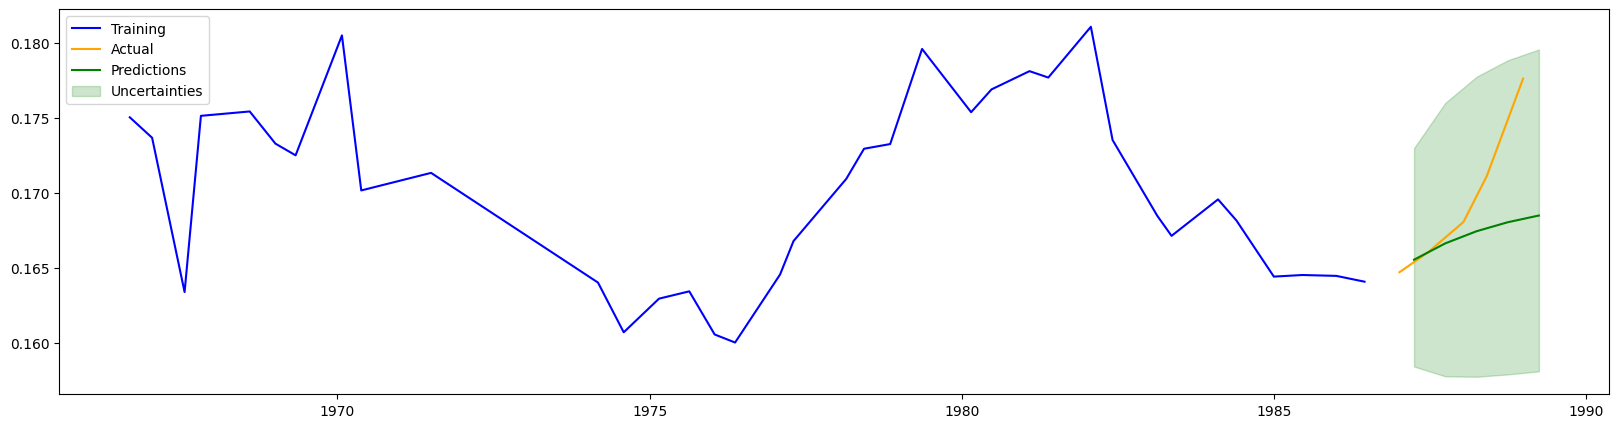

In [142]:
def plot_predictions(trainingset, validset, results):
    fig,ax = plt.subplots(figsize = (20,5))
    ax.plot(trainingset['year'], trainingset['sind'], color = 'blue', label = 'Training')
    ax.plot(validset['year'], validset['sind'], color = 'orange', label = 'Actual')
    results_time = results.index.to_series().apply(lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25)
    ax.plot(results_time, results['forecast'], color = 'green', label = 'Predictions')
    ax.fill_between(results_time, results['lower'], results['upper'], color = 'green', alpha = 0.2, label = 'Uncertainties')
    plt.legend()
    plt.show()

plot_predictions(
    trainingset= train_df_6me,
    validset= valid_df_6me,
    results= results_6me,
                 )